# Sketch to picture mapper

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np

In [2]:
class SketchMapper(nn.Module):
    """
    Sketch Mapper Autorégressif (Es)
    
    Architecture:
    - ResNet50 backbone pour features
    - GRU autorégressif pour prédire latents W+
    - Prédit 10 latents (les 4 derniers sont random pour multi-modalité)
    """
    
    def __init__(
        self,
        latent_dim=256,
        num_latents=12,
        num_predicted=10,  # Prédire 10, randomiser 4
        feature_dim=2048,
        hidden_dim=256
    ):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.num_latents = num_latents
        self.num_predicted = num_predicted
        self.num_random = num_latents - num_predicted
        
        # =====================================
        # 1. FEATURE EXTRACTOR (ResNet50)
        # =====================================
        resnet = models.resnet50(pretrained=True)
        
        # Enlever les couches FC finales -> cad avgpool + fc
        self.feature_extractor = nn.Sequential(
            *list(resnet.children())[:-2]  # Jusqu'à conv5
        )
        
        # Freeze les premières couches (optionnel)
        for param in list(self.feature_extractor.parameters())[:100]:
            param.requires_grad = False
        
        # Feature map: (batch, 2048, H, W)
        self.feature_dim = feature_dim
        
        # =====================================
        # 2. INITIALISATION GRU
        # =====================================
        
        # Global Average Pooling → holistic feature
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # FC pour initialiser hidden state
        self.fc_init = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Tanh()
        )
        
        # =====================================
        # 3. GRU AUTORÉGRESSIF
        # =====================================
        
        self.gru = nn.GRU(
            input_size=latent_dim,  # η(fs, w_{k-1})
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        
        # =====================================
        # 4. INTERACTION fs ⊗ w_{k-1}
        # =====================================
        
        # Projeter feature map pour Hadamard product
        self.feature_proj = nn.Conv2d(
            feature_dim, latent_dim, 
            kernel_size=1
        )
        
        # η(fs, w_{k-1}): extraire info pertinente
        self.eta_network = nn.Sequential(
            nn.Conv2d(latent_dim, latent_dim, 
                     kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(latent_dim, latent_dim, 
                     kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        
        # =====================================
        # 5. PRÉDICTION LATENTS
        # =====================================
        
        # FC partagé pour prédire chaque latent
        self.fc_out = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, sketch, num_steps=None, return_all=False):
        """
        Forward pass
        
        Args:
            sketch: (batch, 3, H, W) ou (batch, 1, H, W)
            num_steps: Nombre de latents à prédire (1-10)
                      Si None, prédit tous (10)
            return_all: Si True, retourne aussi les features
        
        Returns:
            w_plus: (batch, 14, 512) latent code W+
        """
        batch_size = sketch.size(0)
        device = sketch.device
        
        # Si grayscale, répéter sur 3 channels
        if sketch.size(1) == 1:
            sketch = sketch.repeat(1, 3, 1, 1)
        
        # =====================================
        # ÉTAPE 1: Feature Extraction
        # =====================================
        
        fs = self.feature_extractor(sketch)
        # fs: (batch, 2048, H, W)
        
        # Projeter pour Hadamard product
        fs_proj = self.feature_proj(fs)
        # fs_proj: (batch, 512, H, W)
        
        # Global average pooling pour init GRU
        vh = self.gap(fs).squeeze(-1).squeeze(-1)
        # vh: (batch, 2048)
        
        # =====================================
        # ÉTAPE 2: Initialiser GRU
        # =====================================
        
        h0 = self.fc_init(vh)
        # h0: (batch, hidden_dim)
        
        # Reshape pour GRU: (num_layers, batch, hidden_dim)
        hidden = h0.unsqueeze(0).repeat(2, 1, 1)
        
        # =====================================
        # ÉTAPE 3: Prédiction Autoregressive
        # =====================================
        
        # Déterminer nombre de steps
        if num_steps is None:
            num_steps = self.num_predicted
        else:
            num_steps = min(num_steps, self.num_predicted)
        
        predicted_latents = []
        
        # Latent précédent initial: zeros
        w_prev = torch.zeros(batch_size, self.latent_dim).to(device)
        
        for step in range(num_steps):
            # Interaction: fs ⊗ w_{k-1}
            # Broadcast w_prev: (batch, 512) → (batch, 512, 1, 1)
            w_prev_expanded = w_prev.view(batch_size, self.latent_dim, 1, 1)
            
            # Hadamard product
            fs_interaction = fs_proj * w_prev_expanded
            # fs_interaction: (batch, 512, H, W)
            
            # η network: extraire feature pertinente
            eta_out = self.eta_network(fs_interaction)
            # eta_out: (batch, 512)
            
            # GRU step
            # Input: (batch, 1, 512)
            gru_input = eta_out.unsqueeze(1)
            gru_out, hidden = self.gru(gru_input, hidden)
            # gru_out: (batch, 1, hidden_dim)
            
            # Prédire latent
            w_current = self.fc_out(gru_out.squeeze(1))
            # w_current: (batch, 512)
            
            predicted_latents.append(w_current)
            w_prev = w_current
        
        # Stack latents prédits
        predicted_latents = torch.stack(predicted_latents, dim=1)
        # predicted_latents: (batch, num_steps, 512)
        
        # =====================================
        # ÉTAPE 4: Compléter avec Random Latents
        # =====================================
        
        num_random = self.num_latents - num_steps
        
        if num_random > 0:
            # Sample from Gaussian
            random_latents = torch.randn(
                batch_size, num_random, self.latent_dim
            ).to(device)
            
            # Concatener
            w_plus = torch.cat([predicted_latents, random_latents], dim=1)
        else:
            w_plus = predicted_latents
        
        # w_plus: (batch, 14, 512)
        
        if return_all:
            return w_plus, fs, predicted_latents
        else:
            return w_plus


In [3]:
# ============================================================
# PHOTO-TO-PHOTO MAPPER (Teacher)
# ============================================================

class PhotoMapper(nn.Module):
    """
    Photo-to-Photo Mapper (Er) - Identique à SketchMapper mais pour photos
    Utilisé comme Teacher pour la distillation
    """
    
    def __init__(
        self,
        latent_dim=256,
        num_latents=12,
        feature_dim=2048,
        hidden_dim=256
    ):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.num_latents = num_latents
        
        # ResNet50 backbone
        resnet = models.resnet50(pretrained=True)
        self.feature_extractor = nn.Sequential(
            *list(resnet.children())[:-2]
        )
        
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        self.fc_init = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Tanh()
        )
        
        self.gru = nn.GRU(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        
        self.feature_proj = nn.Conv2d(feature_dim, latent_dim, kernel_size=1)
        
        self.eta_network = nn.Sequential(
            nn.Conv2d(latent_dim, latent_dim, 3, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(latent_dim, latent_dim, 3, 2, 1),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        
        self.fc_out = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, photo):
        """Identique à SketchMapper mais pour photos"""
        batch_size = photo.size(0)
        device = photo.device
        
        # Feature extraction
        fs = self.feature_extractor(photo)
        fs_proj = self.feature_proj(fs)
        
        vh = self.gap(fs).squeeze(-1).squeeze(-1)
        h0 = self.fc_init(vh)
        hidden = h0.unsqueeze(0).repeat(2, 1, 1)
        
        # Prédire TOUS les 14 latents (pas de random pour teacher)
        predicted_latents = []
        w_prev = torch.zeros(batch_size, self.latent_dim).to(device)
        
        for step in range(self.num_latents):
            w_prev_expanded = w_prev.view(batch_size, self.latent_dim, 1, 1)
            fs_interaction = fs_proj * w_prev_expanded
            eta_out = self.eta_network(fs_interaction)
            
            gru_input = eta_out.unsqueeze(1)
            gru_out, hidden = self.gru(gru_input, hidden)
            
            w_current = self.fc_out(gru_out.squeeze(1))
            predicted_latents.append(w_current)
            w_prev = w_current
        
        w_plus = torch.stack(predicted_latents, dim=1)
        return w_plus


In [4]:
# ============================================================
# LOSSES
# ============================================================

class SketchMapperLoss(nn.Module):
    """
    Loss combinée pour Sketch Mapper
    
    L_total = λ1*L_rec + λ2*L_LPIPS + λ3*L_disc + λ4*L_KD
    """
    
    def __init__(
        self,
        lpips_model,
        fgsbir_model,
        lambda_rec=1.0,
        lambda_lpips=0.8,
        lambda_disc=0.5,
        lambda_kd=0.6
    ):
        super().__init__()
        
        self.lpips = lpips_model
        self.fgsbir = fgsbir_model
        
        self.lambda_rec = lambda_rec
        self.lambda_lpips = lambda_lpips
        self.lambda_disc = lambda_disc
        self.lambda_kd = lambda_kd
    
    def forward(
        self,
        sketch,
        photo_gt,
        photo_generated,
        latents_student,
        latents_teacher=None
    ):
        """
        Calcule la loss totale
        
        Args:
            sketch: Input sketch
            photo_gt: Ground truth photo
            photo_generated: Photo générée par G(Es(sketch))
            latents_student: Latents prédits par Es
            latents_teacher: Latents prédits par Er (optionnel)
        """
        losses = {}
        
        # 1. Reconstruction Loss (L2)
        loss_rec = F.mse_loss(photo_generated, photo_gt)
        losses['rec'] = loss_rec
        
        # 2. LPIPS Loss (Perceptual)
        loss_lpips = self.lpips(photo_generated, photo_gt).mean()
        losses['lpips'] = loss_lpips
        
        # 3. Fine-Grained Discriminative Loss
        # Cosine similarity in FG-SBIR embedding space
        embed_sketch = self.fgsbir(sketch)
        embed_photo = self.fgsbir(photo_generated)
        
        # Normalize
        embed_sketch = F.normalize(embed_sketch, dim=1)
        embed_photo = F.normalize(embed_photo, dim=1)
        
        # Cosine similarity
        cos_sim = (embed_sketch * embed_photo).sum(dim=1).mean()
        loss_disc = 1 - cos_sim
        losses['disc'] = loss_disc
        
        # 4. Knowledge Distillation Loss (si teacher fourni)
        if latents_teacher is not None:
            # Seulement sur les latents prédits (pas les random)
            num_predicted = latents_student.size(1)
            if num_predicted < latents_teacher.size(1):
                latents_teacher_pred = latents_teacher[:, :num_predicted, :]
            else:
                latents_teacher_pred = latents_teacher
            
            loss_kd = F.mse_loss(latents_student, latents_teacher_pred)
            losses['kd'] = loss_kd
        else:
            losses['kd'] = torch.tensor(0.0).to(photo_gt.device)
        
        # Loss totale
        loss_total = (
            self.lambda_rec * losses['rec'] +
            self.lambda_lpips * losses['lpips'] +
            self.lambda_disc * losses['disc'] +
            self.lambda_kd * losses['kd']
        )
        
        losses['total'] = loss_total
        
        return loss_total, losses

In [5]:
# ============================================================
# FONCTION TEST
# ============================================================

def test_sketch_mapper():
    """Test rapide de l'architecture"""
    
    print("="*60)
    print("🧪 TEST SKETCH MAPPER")
    print("="*60)
    
    # Paramètres
    batch_size = 4
    resolution = 256
    
    # Créer modèles
    print("\n📦 Création modèles...")
    sketch_mapper = SketchMapper(
        latent_dim= 256,
        num_latents=4,
        num_predicted=10
    )
    
    photo_mapper = PhotoMapper(
        latent_dim=256,
        num_latents=12
    )
    
    # Compter paramètres
    params_es = sum(p.numel() for p in sketch_mapper.parameters())
    params_er = sum(p.numel() for p in photo_mapper.parameters())
    
    print(f"   Sketch Mapper (Es): {params_es:,} paramètres")
    print(f"   Photo Mapper (Er):  {params_er:,} paramètres")
    
    # Test forward pass
    print("\n🔄 Test forward pass...")
    
    sketch = torch.randn(batch_size, 1, resolution, resolution)
    photo = torch.randn(batch_size, 3, resolution, resolution)
    
    # Sketch mapper
    with torch.no_grad():
        w_plus_sketch = sketch_mapper(sketch)
        print(f"   ✅ Sketch → W+: {w_plus_sketch.shape}")
        
        # Test avec différents num_steps
        w_plus_partial = sketch_mapper(sketch, num_steps=5)
        print(f"   ✅ Partial (5 steps): {w_plus_partial.shape}")
        
        # Photo mapper
        w_plus_photo = photo_mapper(photo)
        print(f"   ✅ Photo → W+: {w_plus_photo.shape}")
    
    print("\n✅ Test réussi!")
    
    return sketch_mapper, photo_mapper

if __name__ == '__main__':
    test_sketch_mapper()

🧪 TEST SKETCH MAPPER

📦 Création modèles...


/users/eleves-a/2023/roman.lendormy/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/eleves-a/2023/roman.lendormy/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


   Sketch Mapper (Es): 26,592,576 paramètres
   Photo Mapper (Er):  26,592,576 paramètres

🔄 Test forward pass...
   ✅ Sketch → W+: torch.Size([4, 10, 256])
   ✅ Partial (5 steps): torch.Size([4, 5, 256])
   ✅ Photo → W+: torch.Size([4, 12, 256])

✅ Test réussi!


# Passage à l'entrainement

## Entrainement du Photo to Photo Mapper

In [6]:
!pip install lpips

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pickle
from tqdm import tqdm
import lpips

In [8]:
# # CHARGEMENT STYLEGAN
# # ============================================================

# def load_stylegan(checkpoint_path):
#     """Charge le générateur StyleGAN pré-entraîné"""
    
#     print(f"📦 Chargement StyleGAN depuis {checkpoint_path}")
    
#     with open(checkpoint_path, 'rb') as f:
#         data = pickle.load(f)
    
#     # Utiliser G_ema (meilleur que G)
#     if 'G_ema' in data:
#         G = data['G_ema'].cuda()
#     else:
#         G = data['G'].cuda()
    
#     # Freeze
#     for param in G.parameters():
#         param.requires_grad = False
    
#     G.eval()
    
#     print(f"   ✅ z_dim: {G.z_dim}")
#     print(f"   ✅ w_dim: {G.w_dim}")
#     print(f"   ✅ resolution: {G.img_resolution}")
    
#     return G

In [9]:
# ============================================================
# CHARGEMENT STYLEGAN (CORRIGÉ)
# ============================================================

def load_stylegan(checkpoint_path, stylegan_repo_path="/stylegan3"):
    """Charge le générateur StyleGAN3 pré-entraîné correctement"""
    
    import sys
    sys.path.append(stylegan_repo_path)
    
    import legacy
    
    print(f"📦 Chargement StyleGAN depuis {checkpoint_path}")
    
    with open(checkpoint_path, 'rb') as f:
        data = legacy.load_network_pkl(f)
    
    # Toujours utiliser G_ema
    G = data['G_ema'].cuda()
    
    # Freeze
    for param in G.parameters():
        param.requires_grad = False
    
    G.eval()
    
    print(f"   ✅ z_dim: {G.z_dim}")
    print(f"   ✅ w_dim: {G.w_dim}")
    print(f"   ✅ resolution: {G.img_resolution}")
    
    return G

In [10]:
"""
DataLoader pour ShoeV2 dataset
PLUSIEURS sketches par photo (format: photo_id_N.png)
"""

import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import numpy as np
from torchvision import transforms
import re

# ============================================================
# DATASET AVEC MULTI-SKETCHES
# ============================================================

class ShoeV2Dataset(Dataset):
    """
    Dataset pour paires sketch-photo ShoeV2
    
    Format des noms:
    - Sketch: 2429245009_1.png, 2429245009_2.png, 2429245009_20.png
    - Photo:  2429245009.png
    
    Un photo peut avoir N sketches différents
    """
    
    def __init__(
        self,
        root_dir,
        split='train',  # 'train' ou 'test'
        resolution=128,
        augment=True
    ):
        """
        Args:
            root_dir: Chemin vers ShoeV2/
            split: 'train' ou 'test'
            resolution: Taille des images (128 ou 256)
            augment: Data augmentation (seulement pour train)
        """
        
        self.root_dir = Path(root_dir)
        self.split = split
        self.resolution = resolution
        self.augment = augment and (split == 'train')
        
        # Définir dossiers (ignorer *_noise)
        if split == 'train':
            self.sketch_dir = self.root_dir / 'trainA'
            self.photo_dir = self.root_dir / 'trainB'
        else:
            self.sketch_dir = self.root_dir / 'testA'
            self.photo_dir = self.root_dir / 'testB'
        
        # Vérifier existence
        if not self.sketch_dir.exists():
            raise ValueError(f"Dossier sketch introuvable: {self.sketch_dir}")
        if not self.photo_dir.exists():
            raise ValueError(f"Dossier photo introuvable: {self.photo_dir}")
        
        # Lister fichiers
        self.sketch_files = sorted(self.sketch_dir.glob('*.png')) + \
                           sorted(self.sketch_dir.glob('*.jpg'))
        self.photo_files = sorted(self.photo_dir.glob('*.png')) + \
                          sorted(self.photo_dir.glob('*.jpg'))
        
        # Matcher sketches et photos
        self.pairs = self._match_pairs()
        
        print(f"📊 ShoeV2 Dataset ({split}):")
        print(f"   Sketches fichiers: {len(self.sketch_files)}")
        print(f"   Photos fichiers:   {len(self.photo_files)}")
        print(f"   Paires créées:     {len(self.pairs)}")
        
        # Stats
        self._print_stats()
        
        # Transforms
        self._setup_transforms()
    
    def _extract_photo_id(self, filename):
        """
        Extrait l'ID de la photo depuis le nom de fichier
        
        Examples:
            2429245009_1.png  → 2429245009
            2429245009_20.png → 2429245009
            2429245009.png    → 2429245009
        """
        stem = filename.stem  # Sans extension
        
        # Enlever le suffixe _N si présent
        match = re.match(r'^(.+?)(?:_\d+)?$', stem)
        if match:
            return match.group(1)
        return stem
    
    def _match_pairs(self):
        """
        Matcher chaque sketch à sa photo correspondante
        
        Returns:
            List[(sketch_path, photo_path)]
        """
        # Créer mapping photo_id → photo_path
        photo_dict = {}
        for photo_path in self.photo_files:
            photo_id = self._extract_photo_id(photo_path)
            photo_dict[photo_id] = photo_path
        
        # Pour chaque sketch, trouver sa photo
        pairs = []
        unmatched = []
        
        for sketch_path in self.sketch_files:
            photo_id = self._extract_photo_id(sketch_path)
            
            if photo_id in photo_dict:
                pairs.append((sketch_path, photo_dict[photo_id]))
            else:
                unmatched.append(sketch_path.name)
        
        if unmatched:
            print(f"   ⚠️  {len(unmatched)} sketches sans photo correspondante")
            if len(unmatched) <= 10:
                print(f"      Exemples: {unmatched}")
        
        return pairs
    
    def _print_stats(self):
        """Affiche statistiques du dataset"""
        
        # Compter combien de sketches par photo
        from collections import Counter
        
        photo_counts = Counter()
        for sketch_path, photo_path in self.pairs:
            photo_counts[photo_path] += 1
        
        sketches_per_photo = list(photo_counts.values())
        
        print(f"\n   📈 Statistiques sketches par photo:")
        print(f"      Photos uniques:     {len(photo_counts)}")
        print(f"      Min sketches/photo: {min(sketches_per_photo)}")
        print(f"      Max sketches/photo: {max(sketches_per_photo)}")
        print(f"      Moyenne:            {np.mean(sketches_per_photo):.1f}")
        
        # Distribution
        unique_counts = sorted(set(sketches_per_photo))
        print(f"\n   📊 Distribution:")
        for count in unique_counts[:10]:  # Top 10
            n_photos = sum(1 for c in sketches_per_photo if c == count)
            print(f"      {count} sketch(s):  {n_photos} photos")
        
        if len(unique_counts) > 10:
            print(f"      ... et {len(unique_counts)-10} autres valeurs")
    
    def _setup_transforms(self):
        """Setup des transformations"""
        
        # Transform pour sketches (grayscale)
        sketch_transforms = [
            transforms.Resize((self.resolution, self.resolution)),
        ]
        
        if self.augment:
            sketch_transforms.extend([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=5),
                transforms.RandomAffine(
                    degrees=0,
                    translate=(0.05, 0.05),
                    scale=(0.95, 1.05)
                ),
            ])
        
        sketch_transforms.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])  # [-1, 1]
        ])
        
        self.sketch_transform = transforms.Compose(sketch_transforms)
        
        # Transform pour photos (RGB)
        photo_transforms = [
            transforms.Resize((self.resolution, self.resolution)),
        ]
        
        if self.augment:
            photo_transforms.extend([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(
                    brightness=0.1,
                    contrast=0.1,
                    saturation=0.1,
                    hue=0.05
                ),
            ])
        
        photo_transforms.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # [-1, 1]
        ])
        
        self.photo_transform = transforms.Compose(photo_transforms)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        sketch_path, photo_path = self.pairs[idx]
        
        # Charger sketch
        sketch = Image.open(sketch_path).convert('L')  # Grayscale
        sketch = self.sketch_transform(sketch)
        
        # Charger photo
        photo = Image.open(photo_path).convert('RGB')
        photo = self.photo_transform(photo)
        
        # Extraire photo_id
        photo_id = self._extract_photo_id(photo_path)
        
        return {
            'sketch': sketch,           # (1, H, W) range [-1, 1]
            'photo': photo,             # (3, H, W) range [-1, 1]
            'photo_id': photo_id,       # ID unique de la photo
            'sketch_path': str(sketch_path),
            'photo_path': str(photo_path),
        }



In [11]:
# ============================================================
# DATASET PHOTO-ONLY (pour Photo Mapper)
# ============================================================

class PhotoOnlyDataset(Dataset):
    """
    Dataset avec SEULEMENT les photos (pas de duplicates)
    Pour entraîner le Photo Mapper (Phase 1)
    """
    
    def __init__(
        self,
        root_dir,
        split='train',
        resolution=128,
        augment=True
    ):
        self.root_dir = Path(root_dir)
        self.resolution = resolution
        self.augment = augment and (split == 'train')
        
        # Dossier photos
        if split == 'train':
            self.photo_dir = self.root_dir / 'trainB'
        else:
            self.photo_dir = self.root_dir / 'testB'
        
        if not self.photo_dir.exists():
            raise ValueError(f"Dossier photo introuvable: {self.photo_dir}")
        
        # Lister fichiers (photos uniques)
        self.photo_files = sorted(self.photo_dir.glob('*.png')) + \
                          sorted(self.photo_dir.glob('*.jpg'))
        
        print(f"📊 Photo-Only Dataset ({split}):")
        print(f"   Photos uniques: {len(self.photo_files)}")
        
        # Transform
        photo_transforms = [
            transforms.Resize((self.resolution, self.resolution)),
        ]
        
        if self.augment:
            photo_transforms.extend([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(
                    brightness=0.1,
                    contrast=0.1,
                    saturation=0.1,
                    hue=0.05
                ),
            ])
        
        photo_transforms.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
        
        self.photo_transform = transforms.Compose(photo_transforms)
    
    def __len__(self):
        return len(self.photo_files)
    
    def __getitem__(self, idx):
        photo_path = self.photo_files[idx]
        
        photo = Image.open(photo_path).convert('RGB')
        photo = self.photo_transform(photo)
        
        return {
            'photo': photo,
            'photo_path': str(photo_path),
        }



In [12]:
# ============================================================
# AUGMENTATION PARTIELLE
# ============================================================

class PartialSketchAugmentation:
    """
    Augmentation pour sketches partiels
    Selon le papier: 30-100% du sketch, par paliers de 10%
    """
    
    def __init__(self, min_completion=0.3, max_completion=1.0, step=0.1):
        self.completions = np.arange(min_completion, max_completion + step, step)
    
    def __call__(self, sketch):
        """
        Rend le sketch partiellement visible
        
        Args:
            sketch: (1, H, W) tensor
        
        Returns:
            sketch_partial: (1, H, W) tensor
            completion_ratio: float (0.3 - 1.0)
            num_steps: int (3-10) nombre de latents à prédire
        """
        # Choisir ratio aléatoire
        completion = np.random.choice(self.completions)
        
        # Calculer nombre de steps (3-10 pour 30%-100%)
        # 30% → 3 latents, 100% → 10 latents
        num_steps = int(3 + (completion - 0.3) / 0.7 * 7)
        num_steps = np.clip(num_steps, 3, 10)
        
        if completion >= 1.0:
            return sketch, completion, num_steps
        
        # Masquer une portion du sketch
        # Stratégie: masquer verticalement (de bas en haut)
        H = sketch.size(-2)
        visible_height = int(H * completion)
        
        sketch_partial = sketch.clone()
        sketch_partial[:, visible_height:, :] = 1.0  # Blanc (background)
        
        return sketch_partial, completion, num_steps



In [13]:
# ============================================================
# DATALOADER FACTORY
# ============================================================

def create_dataloaders(
    root_dir='/Data/roman.lendormy/pairs-sketch/ShoeV2',
    resolution=128,
    batch_size=8,
    num_workers=4
):
    """
    Crée tous les dataloaders nécessaires
    
    Returns:
        dict avec:
        - 'photo_train': Pour entraîner Photo Mapper
        - 'photo_val': Pour valider Photo Mapper
        - 'pair_train': Pour entraîner Sketch Mapper
        - 'pair_val': Pour valider Sketch Mapper
    """
    
    print("="*60)
    print("📦 CRÉATION DATALOADERS")
    print("="*60)
    
    # Photo Mapper datasets
    print("\n🖼️  Photo-Only Datasets:")
    photo_train = PhotoOnlyDataset(
        root_dir=root_dir,
        split='train',
        resolution=resolution,
        augment=True
    )
    
    photo_val = PhotoOnlyDataset(
        root_dir=root_dir,
        split='test',
        resolution=resolution,
        augment=False
    )
    
    # Sketch-Photo pair datasets
    print("\n🎨 Sketch-Photo Pair Datasets:")
    pair_train = ShoeV2Dataset(
        root_dir=root_dir,
        split='train',
        resolution=resolution,
        augment=True
    )
    
    pair_val = ShoeV2Dataset(
        root_dir=root_dir,
        split='test',
        resolution=resolution,
        augment=False
    )
    
    # DataLoaders
    dataloaders = {
        'photo_train': DataLoader(
            photo_train,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True,
            drop_last=True
        ),
        
        'photo_val': DataLoader(
            photo_val,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True
        ),
        
        'pair_train': DataLoader(
            pair_train,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True,
            drop_last=True
        ),
        
        'pair_val': DataLoader(
            pair_val,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True
        ),
    }
    
    print("\n" + "="*60)
    print("✅ DataLoaders créés:")
    for name, loader in dataloaders.items():
        print(f"   {name:15} {len(loader):5} batches")
    print("="*60)
    
    return dataloaders

In [14]:
# ============================================================
# LOSS
# ============================================================

class PhotoMapperLoss(nn.Module):
    """Loss pour Photo Mapper: reconstruction + perceptual"""
    
    def __init__(self):
        super().__init__()
        
        # LPIPS loss (perceptual)
        self.lpips = lpips.LPIPS(net='vgg').cuda()
        
        # Freeze LPIPS
        for param in self.lpips.parameters():
            param.requires_grad = False
    
    def forward(self, photo_input, photo_reconstructed):
        """
        Args:
            photo_input: Photo d'entrée (GT)
            photo_reconstructed: G(Er(photo_input))
        """
        # L2 reconstruction
        loss_rec = torch.nn.functional.mse_loss(photo_reconstructed, photo_input)
        
        # LPIPS perceptual
        loss_lpips = self.lpips(photo_reconstructed, photo_input).mean()
        
        # Combiné
        loss_total = loss_rec + 0.8 * loss_lpips
        
        return loss_total, {
            'rec': loss_rec.item(),
            'lpips': loss_lpips.item(),
        }


In [20]:
# ============================================================
# TRAINING LOOP
# ============================================================

def train_photo_mapper(
    dataset_root,  # ← Changé: root du dataset ShoeV2
    stylegan_checkpoint,
    output_dir='./checkpoints_photo_mapper',
    num_epochs=50,
    batch_size=8,
    lr=1e-5,
    resolution=128,
    num_workers=4,
    save_frequency=10,
    validate_frequency=5
):
    """
    Entraîne le Photo Mapper (Teacher Er)
    
    Args:
        dataset_root: Chemin vers ShoeV2/ (contient trainB/, testB/)
        stylegan_checkpoint: Checkpoint StyleGAN pré-entraîné
        num_epochs: Nombre d'epochs
        batch_size: Taille des batches
        lr: Learning rate
        resolution: Résolution des images (128 ou 256)
        num_workers: Nombre de workers DataLoader
        save_frequency: Sauvegarder tous les N epochs
        validate_frequency: Valider tous les N epochs
    """
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print("="*60)
    print("🎓 PHASE 1: ENTRAÎNEMENT PHOTO MAPPER (TEACHER)")
    print("="*60)
    
    # =====================================
    # 1. Charger StyleGAN
    # =====================================
    
    G = load_stylegan(stylegan_checkpoint)
    
    # =====================================
    # 2. Créer Photo Mapper
    # =====================================
    
    print("\n📦 Création Photo Mapper...")

    
    photo_mapper = PhotoMapper(
        latent_dim=G.w_dim,
        num_latents=12,
        feature_dim=2048,
        hidden_dim=256
    ).cuda()
    
    params = sum(p.numel() for p in photo_mapper.parameters() if p.requires_grad)
    print(f"   Paramètres entraînables: {params:,}")
    
    # =====================================
    # 3. Dataset & DataLoader
    # =====================================
    
    print("\n📊 Chargement datasets...")
    
    # Créer datasets
    train_dataset = PhotoOnlyDataset(
        root_dir=dataset_root,
        split='train',
        resolution=resolution,
        augment=True
    )
    
    val_dataset = PhotoOnlyDataset(
        root_dir=dataset_root,
        split='test',
        resolution=resolution,
        augment=False
    )
    
    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    print(f"   Train: {len(train_dataset)} photos → {len(train_loader)} batches")
    print(f"   Val:   {len(val_dataset)} photos → {len(val_loader)} batches")
    
    # =====================================
    # 4. Loss & Optimizer
    # =====================================
    
    criterion = PhotoMapperLoss()
    
    optimizer = optim.Adam(
        photo_mapper.parameters(),
        lr=lr,
        betas=(0.9, 0.999),
        weight_decay=1e-5
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
        verbose=True
    )
    
    # Mixed Precision Scaler
    scaler = torch.cuda.amp.GradScaler()
    
    # =====================================
    # 5. Training Loop
    # =====================================
    
    print("\n🚀 Démarrage entraînement...\n")
    
    best_val_loss = float('inf')
    history = {
        'train_loss': [],
        'train_rec': [],
        'train_lpips': [],
        'val_loss': [],
        'val_rec': [],
        'val_lpips': [],
    }
    
    for epoch in range(num_epochs):
        
        # =====================================
        # TRAINING
        # =====================================
        
        photo_mapper.train()
        
        epoch_losses = {'rec': [], 'lpips': [], 'total': []}
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        
        for batch_idx, batch in enumerate(pbar):
            photo = batch['photo'].cuda()
            
            optimizer.zero_grad()
            
            # Forward with mixed precision
            with torch.cuda.amp.autocast(enabled=False):
                w_plus = photo_mapper(photo)
                #Debug + enabled mis à false dans autocast pour vérifier dtype et device de w_plus
                # print("w_plus.shape =", w_plus.shape)
                # print("G.num_ws =", G.num_ws)
                # print("G.w_dim =", G.w_dim)
                # device = next(G.parameters()).device  # prend le device du premier paramètre
                # w_plus = w_plus.float().to(device)
                # print("dtype:", w_plus.dtype)
                # print("device:", w_plus.device)
                #Fin debug
                photo_reconstructed = G.synthesis(w_plus)
                
                # Loss
                loss_total, losses_dict = criterion(photo, photo_reconstructed)
            
            # Backward with scaler
            scaler.scale(loss_total).backward()
            
            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(photo_mapper.parameters(), max_norm=1.0)
            
            # Optimizer step
            scaler.step(optimizer)
            scaler.update()
            
            # Log
            epoch_losses['total'].append(loss_total.item())
            epoch_losses['rec'].append(losses_dict['rec'])
            epoch_losses['lpips'].append(losses_dict['lpips'])
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f"{loss_total.item():.4f}",
                'rec': f"{losses_dict['rec']:.4f}",
                'lpips': f"{losses_dict['lpips']:.4f}",
            })
        
        # Epoch summary
        avg_train_loss = np.mean(epoch_losses['total'])
        avg_train_rec = np.mean(epoch_losses['rec'])
        avg_train_lpips = np.mean(epoch_losses['lpips'])
        
        history['train_loss'].append(avg_train_loss)
        history['train_rec'].append(avg_train_rec)
        history['train_lpips'].append(avg_train_lpips)
        
        print(f"\n📊 Epoch {epoch+1}/{num_epochs} - Train:")
        print(f"   Total Loss: {avg_train_loss:.4f}")
        print(f"   Rec Loss:   {avg_train_rec:.4f}")
        print(f"   LPIPS Loss: {avg_train_lpips:.4f}")
        
        # =====================================
        # VALIDATION
        # =====================================
        
        if (epoch + 1) % validate_frequency == 0 or epoch == 0:
            photo_mapper.eval()
            
            val_losses = {'rec': [], 'lpips': [], 'total': []}
            
            with torch.no_grad():
                pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
                
                for batch in pbar_val:
                    photo = batch['photo'].cuda()
                    
                    with torch.cuda.amp.autocast(enabled=False):
                        w_plus = photo_mapper(photo)
                        photo_reconstructed = G.synthesis(w_plus)
                        
                        loss_total, losses_dict = criterion(photo, photo_reconstructed)
                    
                    val_losses['total'].append(loss_total.item())
                    val_losses['rec'].append(losses_dict['rec'])
                    val_losses['lpips'].append(losses_dict['lpips'])
                    
                    pbar_val.set_postfix({
                        'loss': f"{loss_total.item():.4f}",
                    })
            
            avg_val_loss = np.mean(val_losses['total'])
            avg_val_rec = np.mean(val_losses['rec'])
            avg_val_lpips = np.mean(val_losses['lpips'])
            
            history['val_loss'].append(avg_val_loss)
            history['val_rec'].append(avg_val_rec)
            history['val_lpips'].append(avg_val_lpips)
            
            print(f"\n📊 Epoch {epoch+1}/{num_epochs} - Val:")
            print(f"   Total Loss: {avg_val_loss:.4f}")
            print(f"   Rec Loss:   {avg_val_rec:.4f}")
            print(f"   LPIPS Loss: {avg_val_lpips:.4f}")
            
            # Scheduler step
            scheduler.step(avg_val_loss)
            
        #     # Save best model
        #     if avg_val_loss < best_val_loss:
        #         best_val_loss = avg_val_loss
                
        #         checkpoint = {
        #             'epoch': epoch,
        #             'model_state_dict': photo_mapper.state_dict(),
        #             'optimizer_state_dict': optimizer.state_dict(),
        #             'scheduler_state_dict': scheduler.state_dict(),
        #             'scaler_state_dict': scaler.state_dict(),
        #             'train_loss': avg_train_loss,
        #             'val_loss': avg_val_loss,
        #             'best_val_loss': best_val_loss,
        #             'config': {
        #                 'latent_dim': G.w_dim,
        #                 'num_latents': 14,
        #                 'resolution': resolution,
        #                 'feature_dim': 2048,
        #                 'hidden_dim': 256,
        #             }
        #         }
                
        #         checkpoint_path = output_dir / 'photo_mapper_best.pt'
        #         torch.save(checkpoint, checkpoint_path)
                
        #         print(f"   ✅ Meilleur modèle sauvegardé: {checkpoint_path}")
        
        # # =====================================
        # # SAVE PERIODIC CHECKPOINT
        # # =====================================
        
        # if (epoch + 1) % save_frequency == 0:
        #     checkpoint_path = output_dir / f'photo_mapper_epoch_{epoch+1:03d}.pt'
        #     checkpoint = {
        #         'epoch': epoch,
        #         'model_state_dict': photo_mapper.state_dict(),
        #         'optimizer_state_dict': optimizer.state_dict(),
        #         'scheduler_state_dict': scheduler.state_dict(),
        #         'train_loss': avg_train_loss,
        #         'history': history,
        #         'config': {
        #             'latent_dim': G.w_dim,
        #             'num_latents': 12,
        #             'resolution': resolution,
        #         }
        #     }
        #     torch.save(checkpoint, checkpoint_path)
        #     print(f"   💾 Checkpoint périodique: {checkpoint_path}")
        
        # print()
    
    # =====================================
    # SAVE FINAL MODEL
    # =====================================
    
    final_checkpoint = {
        'epoch': num_epochs - 1,
        'model_state_dict': photo_mapper.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'best_val_loss': best_val_loss,
        'config': {
            'latent_dim': G.w_dim,
            'num_latents': 14,
            'resolution': resolution,
        }
    }
    
    final_path = output_dir / 'photo_mapper_final.pt'
    torch.save(final_checkpoint, final_path)
    
    # Save history as JSON
    import json
    history_path = output_dir / 'training_history.json'
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    
    print("\n" + "="*60)
    print("✅ PHASE 1 TERMINÉE")
    print(f"   Meilleur val loss: {best_val_loss:.4f}")
    print(f"   Checkpoints sauvegardés dans: {output_dir}")
    print(f"   - photo_mapper_best.pt (meilleur modèle)")
    print(f"   - photo_mapper_final.pt (dernier epoch)")
    print(f"   - training_history.json (courbes)")
    print("="*60)
    
    return photo_mapper, history



In [16]:
# ============================================================
# VISUALISATION RÉSULTATS
# ============================================================

def visualize_training_history(history_path, output_path='training_curves.png'):
    """Visualise les courbes d'entraînement"""
    
    import json
    import matplotlib.pyplot as plt
    
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Total Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
    # if history['val_loss']:
    #     val_epochs = range(1, len(history['train_loss']) + 1, 
    #                       len(history['train_loss']) // len(history['val_loss']))
    #     axes[0].plot(val_epochs, history['val_loss'], 'r-', label='Val')
    
    # Total Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')

    if history['val_loss']:
        # Epochs réels où la validation a été faite
        val_epochs = np.linspace(
            1,
            len(history['train_loss']),
            num=len(history['val_loss'])
        )

        # Interpolation sur tous les epochs
        val_interp = np.interp(
            epochs,          # où on veut les valeurs
            val_epochs,      # x connus
            history['val_loss']  # y connus
        )

        axes[0].plot(epochs, val_interp, 'r--', label='Val (interp)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Total Loss')
    axes[0].set_title('Total Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Reconstruction Loss
    axes[1].plot(epochs, history['train_rec'], 'b-', label='Train')
    if history['val_rec']:
        axes[1].plot(val_epochs, history['val_rec'], 'r-', label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Reconstruction Loss')
    axes[1].set_title('L2 Reconstruction Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # LPIPS Loss
    axes[2].plot(epochs, history['train_lpips'], 'b-', label='Train')
    if history['val_lpips']:
        axes[2].plot(val_epochs, history['val_lpips'], 'r-', label='Val')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LPIPS Loss')
    axes[2].set_title('Perceptual Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Courbes sauvegardées: {output_path}")


In [ ]:
# import de legacy et dnnlib depuis le repo stylegan3 (pour éviter conflits avec d'autres versions)

import sys
from pathlib import Path

project_dir = Path('/users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project')
repo_path = project_dir / 'stylegan3'
sys.path.insert(0, str(repo_path))

for m in ["legacy", "dnnlib", "torch_utils"]:
    if m in sys.modules:
        del sys.modules[m]

import dnnlib
import legacy
import torch

print("✅ legacy chargé depuis:", legacy.__file__)  # Doit renvoyer le repo stylegan3
print("✅ dnnlib chargé depuis:", dnnlib.__file__)

✅ legacy chargé depuis: /users/eleves-a/2023/roman.lendormy/multimodal_genai/Project/stylegan3/legacy.py
✅ dnnlib chargé depuis: /users/eleves-a/2023/roman.lendormy/multimodal_genai/Project/stylegan3/dnnlib/__init__.py


In [ ]:
# Chemins (corrigés pour le workspace local)
from pathlib import Path

project_dir = Path('/users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project')

# Détection automatique d'un dossier dataset pairé (trainA/trainB/testA/testB)
dataset_candidates = [
    project_dir / 'ChairsV2',
    project_dir / 'chairs_pairs',
    project_dir / 'pairs-sketch' / 'ChairsV2',
    project_dir / 'ShoeV2'  # fallback si ton dossier n'est pas encore renommé
 ]

dataset_root_path = next((p for p in dataset_candidates if p.exists()), dataset_candidates[0])
dataset_root = str(dataset_root_path)

# Checkpoint StyleGAN chairs: prend le dernier snapshot disponible
checkpoint_dir = project_dir / 'stylegan3_training_chairs'
snapshots = sorted(checkpoint_dir.glob('network-snapshot-*.pkl'))
stylegan_checkpoint = str(snapshots[-1]) if snapshots else str(checkpoint_dir / 'network-snapshot-011200.pkl')

output_dir = str(project_dir / 'checkpoints_photo_mapper')

print(f"📁 dataset_root = {dataset_root}")
print(f"📦 stylegan_checkpoint = {stylegan_checkpoint}")
print(f"💾 output_dir = {output_dir}")

# Entraîner
photo_mapper, history = train_photo_mapper(
    dataset_root=dataset_root,
    stylegan_checkpoint=stylegan_checkpoint,
    output_dir=output_dir,
    num_epochs=1000,  # 300 à 400 suffit souvent
    batch_size=8,
    lr=1e-5,
    resolution=128,
    num_workers=4,
    save_frequency=10,
    validate_frequency=1
)

print("\n🎉 PHOTO MAPPER ENTRAÎNÉ!")

🎓 PHASE 1: ENTRAÎNEMENT PHOTO MAPPER (TEACHER)
📦 Chargement StyleGAN depuis /Data/roman.lendormy/stylegan3_training_shoes/network-snapshot-017600.pkl
   ✅ z_dim: 256
   ✅ w_dim: 256
   ✅ resolution: 128

📦 Création Photo Mapper...
   Paramètres entraînables: 26,592,576

📊 Chargement datasets...
📊 Photo-Only Dataset (train):
   Photos uniques: 1800
📊 Photo-Only Dataset (test):
   Photos uniques: 200
   Train: 1800 photos → 225 batches
   Val:   200 photos → 25 batches
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /users/eleves-a/2023/roman.lendormy/.local/lib/python3.9/site-packages/lpips/weights/v0.1/vgg.pth

🚀 Démarrage entraînement...



Epoch 1/1000 [Train]: 100%|██████████| 225/225 [00:29<00:00,  7.59it/s, loss=0.5610, rec=0.2736, lpips=0.3593]



📊 Epoch 1/1000 - Train:
   Total Loss: 0.5692
   Rec Loss:   0.2909
   LPIPS Loss: 0.3479


Epoch 1/1000 [Val]: 100%|██████████| 25/25 [00:01<00:00, 18.50it/s, loss=0.4545]



📊 Epoch 1/1000 - Val:
   Total Loss: 0.4882
   Rec Loss:   0.2301
   LPIPS Loss: 0.3226


...


📊 Epoch 999/1000 - Val:
   Total Loss: 0.1754
   Rec Loss:   0.0454
   LPIPS Loss: 0.1625


Epoch 1000/1000 [Train]: 100%|██████████| 225/225 [00:29<00:00,  7.51it/s, loss=0.1896, rec=0.0554, lpips=0.1676]



📊 Epoch 1000/1000 - Train:
   Total Loss: 0.1778
   Rec Loss:   0.0452
   LPIPS Loss: 0.1657


Epoch 1000/1000 [Val]: 100%|██████████| 25/25 [00:01<00:00, 18.43it/s, loss=0.1271]



📊 Epoch 1000/1000 - Val:
   Total Loss: 0.1748
   Rec Loss:   0.0451
   LPIPS Loss: 0.1621

✅ PHASE 1 TERMINÉE
   Meilleur val loss: inf
   Checkpoints sauvegardés dans: Data/roman.lendormy/checkpoints_photo_mapper
   - photo_mapper_best.pt (meilleur modèle)
   - photo_mapper_final.pt (dernier epoch)
   - training_history.json (courbes)


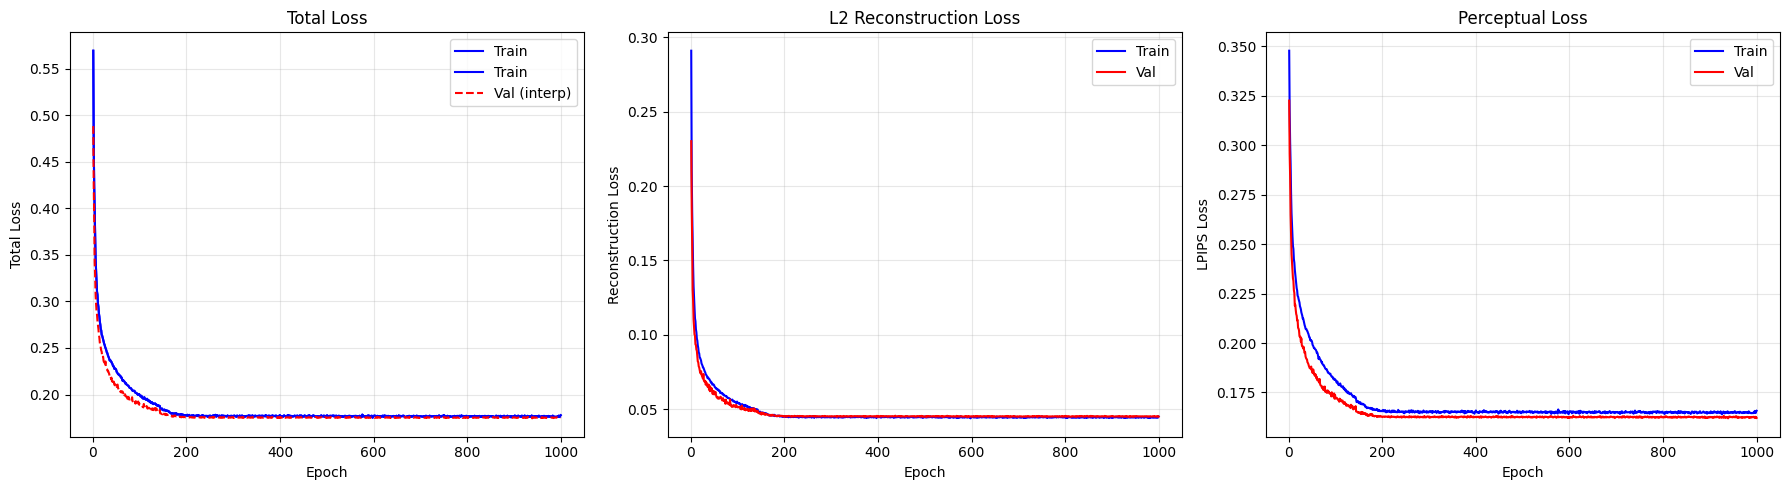

✅ Courbes sauvegardées: Data/roman.lendormy/checkpoints_photo_mapper/training_curves.png


In [ ]:
# Visualiser courbes
visualize_training_history(
    '/Data/roman.lendormy/checkpoints_photo_mapper/training_history.json',
    '/Data/roman.lendormy/checkpoints_photo_mapper/training_curves.png'
)

In [32]:
# ============================================================
# SAUVEGARDER LE MODÈLE MAINTENANT
# ============================================================

from pathlib import Path
import torch

# Le modèle est toujours dans la variable photo_mapper
print("📦 Sauvegarde du modèle entraîné...")

output_dir = Path('Data/roman.lendormy/checkpoints_photo_mapper')
output_dir.mkdir(parents=True, exist_ok=True)

# Essayer plusieurs emplacements
save_locations = [
    output_dir / 'photo_mapper_trained_RECOVERED.pt',
    Path('/Data/roman.lendormy/photo_mapper_trained.pt'),
    Path('/tmp/photo_mapper_trained.pt'),
]

saved = False
for save_path in save_locations:
    try:
        # Sauvegarder le modèle complet
        checkpoint = {
            'model_state_dict': photo_mapper.state_dict(),
            'history': history,
            'config': {
                'latent_dim': 256,
                'num_latents': 12,
                'resolution': 128,
                'feature_dim': 2048,
                'hidden_dim': 512,
            }
        }
        
        torch.save(checkpoint, save_path)
        print(f"✅ Sauvegardé: {save_path}")
        saved = True
        break
        
    except Exception as e:
        print(f"❌ {save_path}: {e}")

if not saved:
    print("\n⚠️  TOUTES LES TENTATIVES ONT ÉCHOUÉ")
    print("Le modèle est toujours en mémoire dans 'photo_mapper'")

📦 Sauvegarde du modèle entraîné...
✅ Sauvegardé: Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_trained_RECOVERED.pt


In [33]:
# ============================================================
# TESTER LE CHARGEMENT D'UN CHECKPOINT
# ============================================================

import torch

# REMPLACEZ CE CHEMIN par celui trouvé ci-dessus
checkpoint_path = '/Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_best.pt'  # ← MODIFIER

checkpoint_path = Path(checkpoint_path)

print(f"🧪 TEST DE CHARGEMENT")
print(f"   Fichier: {checkpoint_path.name}")
print(f"   Chemin: {checkpoint_path}")

if checkpoint_path.exists():
    print(f"   ✅ Fichier existe")
    print(f"   Taille: {checkpoint_path.stat().st_size / (1024**2):.1f} MB")
    
    try:
        # Charger le checkpoint
        print("\n📦 Chargement...")
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        
        print(f"✅ CHARGEMENT RÉUSSI!")
        print(f"\n📋 Contenu du checkpoint:")
        print(f"   Clés: {list(checkpoint.keys())}")
        
        # Afficher détails
        if 'epoch' in checkpoint:
            print(f"\n   Epoch: {checkpoint['epoch']}")
        
        if 'val_loss' in checkpoint:
            print(f"   Val Loss: {checkpoint['val_loss']:.4f}")
        
        if 'train_loss' in checkpoint:
            print(f"   Train Loss: {checkpoint['train_loss']:.4f}")
        
        if 'config' in checkpoint:
            print(f"\n   Configuration:")
            for key, val in checkpoint['config'].items():
                print(f"      {key}: {val}")
        
        if 'history' in checkpoint:
            hist = checkpoint['history']
            if 'train_loss' in hist:
                n_epochs = len(hist['train_loss'])
                print(f"\n   Historique: {n_epochs} epochs")
                if n_epochs > 0:
                    print(f"      Premier train loss: {hist['train_loss'][0]:.4f}")
                    print(f"      Dernier train loss: {hist['train_loss'][-1]:.4f}")
        
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
            print(f"\n   État du modèle:")
            print(f"      {len(state_dict)} paramètres")
            print(f"      Première clé: {list(state_dict.keys())[0]}")
        
        print("\n✅ CE FICHIER EST VALIDE!")
        
    except Exception as e:
        print(f"\n❌ ERREUR DE CHARGEMENT: {e}")
        print(f"   Le fichier est peut-être corrompu")

else:
    print(f"   ❌ Fichier introuvable")
    print(f"\n💡 Chemins testés:")
    print(f"      {checkpoint_path}")
    print(f"      {checkpoint_path.absolute()}")

🧪 TEST DE CHARGEMENT
   Fichier: photo_mapper_best.pt
   Chemin: /Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_best.pt
   ❌ Fichier introuvable

💡 Chemins testés:
      /Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_best.pt
      /Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_best.pt


# Entrainement du Sketch Mapper

In [46]:
# ============================================================
# CORRIGER LE CHARGEMENT DU PHOTO MAPPER
# ============================================================

def train_sketch_mapper(
    dataset_root,
    stylegan_checkpoint,
    photo_mapper_checkpoint,
    output_dir='/Data/roman.lendormy/checkpoints_sketch_mapper',
    num_epochs=100,
    batch_size=8,
    lr=1e-5,
    resolution=128,
    num_workers=4,
    save_frequency=10,
    validate_frequency=5
):
    """Entraîne le Sketch Mapper avec distillation"""
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print("="*60)
    print("🎨 PHASE 3: ENTRAÎNEMENT SKETCH MAPPER (STUDENT)")
    print("="*60)
    
    # =====================================
    # 1. Charger StyleGAN
    # =====================================
    
    G = load_stylegan(stylegan_checkpoint)
    
    # =====================================
    # 2. Charger Photo Mapper (Teacher) - CORRIGÉ
    # =====================================
    
    print(f"\n📦 Chargement Photo Mapper (Teacher)...")
    print(f"   Checkpoint: {Path(photo_mapper_checkpoint).name}")
    
    # ✅ CHARGER LE CHECKPOINT D'ABORD pour lire la config
    checkpoint = torch.load(photo_mapper_checkpoint, map_location='cpu')
    
    # Lire la config depuis le checkpoint
    if 'config' in checkpoint:
        config = checkpoint['config']
        print(f"\n   Config trouvée dans checkpoint:")
        print(f"      latent_dim: {config.get('latent_dim', G.w_dim)}")
        print(f"      num_latents: {config.get('num_latents', G.num_ws)}")
        print(f"      hidden_dim: {config.get('hidden_dim', 512)}")
        print(f"      feature_dim: {config.get('feature_dim', 2048)}")
        
        # ✅ UTILISER LA CONFIG DU CHECKPOINT
        teacher_hidden_dim = config.get('hidden_dim', 512)
        teacher_feature_dim = config.get('feature_dim', 2048)
    else:
        print(f"\n   ⚠️  Pas de config, détection automatique...")
        
        # Détecter depuis les poids
        state_dict = checkpoint['model_state_dict']
        
        # Le fc_init fait: feature_dim → hidden_dim
        fc_init_weight = state_dict['fc_init.0.weight']
        teacher_hidden_dim = fc_init_weight.shape[0]
        teacher_feature_dim = fc_init_weight.shape[1]
        
        print(f"      hidden_dim détecté: {teacher_hidden_dim}")
        print(f"      feature_dim détecté: {teacher_feature_dim}")
    
    # ✅ CRÉER PHOTO MAPPER AVEC LA BONNE CONFIG
    photo_mapper = PhotoMapper(
        latent_dim=G.w_dim,
        num_latents=G.num_ws,
        feature_dim=teacher_feature_dim,  # ← Config du checkpoint
        hidden_dim=teacher_hidden_dim     # ← Config du checkpoint
    ).cuda()
    
    # Charger les poids
    photo_mapper.load_state_dict(checkpoint['model_state_dict'])
    
    # Freeze
    for param in photo_mapper.parameters():
        param.requires_grad = False
    
    photo_mapper.eval()
    
    print(f"   ✅ Teacher chargé et frozen")
    
    # =====================================
    # 3. Créer Sketch Mapper (Student)
    # =====================================
    
    print(f"\n📦 Création Sketch Mapper (Student)...")
    
    # ✅ IMPORTANT: Student peut avoir sa propre config
    # Mais généralement on utilise la même que le teacher
    sketch_mapper = SketchMapper(
        latent_dim=G.w_dim,
        num_latents=G.num_ws,
        num_predicted=10,        # Prédire 10, randomiser 2
        feature_dim=teacher_feature_dim,  # Même que teacher
        hidden_dim=teacher_hidden_dim     # Même que teacher
    ).cuda()
    
    params = sum(p.numel() for p in sketch_mapper.parameters() if p.requires_grad)
    print(f"   Paramètres: {params:,}")
    
    # =====================================
    # 4. Dataset (PAIRES sketch-photo)
    # =====================================
    
    print(f"\n📊 Chargement datasets (paires sketch-photo)...")
    
    train_dataset = ShoeV2Dataset(
        root_dir=dataset_root,
        split='train',
        resolution=resolution,
        augment=True
    )
    
    val_dataset = ShoeV2Dataset(
        root_dir=dataset_root,
        split='test',
        resolution=resolution,
        augment=False
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    print(f"   Train: {len(train_dataset)} paires → {len(train_loader)} batches")
    print(f"   Val:   {len(val_dataset)} paires → {len(val_loader)} batches")
    
    # =====================================
    # 5. Loss & Optimizer
    # =====================================
    
    print(f"\n📦 Configuration loss et optimizer...")
    
    # LPIPS
    lpips_model = lpips.LPIPS(net='vgg').cuda()
    for param in lpips_model.parameters():
        param.requires_grad = False
    
    # Loss
    criterion = SketchMapperLoss(
        lpips_model=lpips_model,
        fgsbir_model=None,
        lambda_rec=1.0,
        lambda_lpips=0.8,
        lambda_disc=0.5,
        lambda_kd=0.6
    )
    
    optimizer = optim.Adam(
        sketch_mapper.parameters(),
        lr=lr,
        betas=(0.9, 0.999),
        weight_decay=1e-5
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        verbose=True
    )
    
    scaler = torch.cuda.amp.GradScaler()
    
    # =====================================
    # 6. Training Loop
    # =====================================
    
    print(f"\n🚀 Démarrage entraînement...\n")
    
    best_val_loss = float('inf')
    history = {
        'train_loss': [], 'train_rec': [], 'train_lpips': [],
        'train_disc': [], 'train_kd': [],
        'val_loss': [], 'val_rec': [], 'val_lpips': [],
        'val_disc': [], 'val_kd': [],
    }
    
    for epoch in range(num_epochs):
        
        # ===== TRAINING =====
        sketch_mapper.train()
        epoch_losses = {
            'total': [], 'rec': [], 'lpips': [], 'disc': [], 'kd': []
        }
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        
        for batch in pbar:
            sketch = batch['sketch'].cuda()
            photo_gt = batch['photo'].cuda()
            
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast(enabled=False):
                # Forward Student
                w_plus_student, _, predicted_latents = sketch_mapper(
                    sketch, return_all=True
                )
                photo_generated = G.synthesis(w_plus_student)
                
                # Forward Teacher
                with torch.no_grad():
                    w_plus_teacher = photo_mapper(photo_gt)
                
                # Loss
                loss_total, losses_dict = criterion(
                    sketch,
                    photo_gt,
                    photo_generated,
                    predicted_latents,
                    w_plus_teacher
                )
            
            # Backward
            scaler.scale(loss_total).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(sketch_mapper.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            
            # Log
            for key in ['total', 'rec', 'lpips', 'disc', 'kd']:
                epoch_losses[key].append(losses_dict[key].item())
            
            pbar.set_postfix({
                'loss': f"{loss_total.item():.4f}",
                'rec': f"{losses_dict['rec'].item():.4f}",
                'kd': f"{losses_dict['kd'].item():.4f}",
            })
        
        # Epoch summary
        for key in epoch_losses:
            history[f'train_{key}'].append(np.mean(epoch_losses[key]))
        
        print(f"\n📊 Epoch {epoch+1}/{num_epochs} - Train:")
        print(f"   Total: {history['train_total'][-1]:.4f}")
        print(f"   Rec: {history['train_rec'][-1]:.4f}")
        print(f"   KD: {history['train_kd'][-1]:.4f}")
        
        # ===== VALIDATION =====
        if (epoch + 1) % validate_frequency == 0 or epoch == 0:
            sketch_mapper.eval()
            val_losses = {
                'total': [], 'rec': [], 'lpips': [], 'disc': [], 'kd': []
            }
            
            with torch.no_grad():
                for batch in tqdm(val_loader, desc="Val"):
                    sketch = batch['sketch'].cuda()
                    photo_gt = batch['photo'].cuda()
                    
                    with torch.cuda.amp.autocast(enabled=False):
                        w_plus_student, _, predicted_latents = sketch_mapper(
                            sketch, return_all=True
                        )
                        photo_generated = G.synthesis(w_plus_student)
                        w_plus_teacher = photo_mapper(photo_gt)
                        
                        loss_total, losses_dict = criterion(
                            sketch, photo_gt, photo_generated,
                            predicted_latents, w_plus_teacher
                        )
                    
                    for key in ['total', 'rec', 'lpips', 'disc', 'kd']:
                        val_losses[key].append(losses_dict[key].item())
            
            for key in val_losses:
                history[f'val_{key}'].append(np.mean(val_losses[key]))
            
            avg_val_loss = history['val_total'][-1]
            
            print(f"\n📊 Epoch {epoch+1}/{num_epochs} - Val:")
            print(f"   Total: {avg_val_loss:.4f}")
            print(f"   Rec: {history['val_rec'][-1]:.4f}")
            print(f"   KD: {history['val_kd'][-1]:.4f}")
            
            scheduler.step(avg_val_loss)
            
            # Save best
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                
                try:
                    safe_loss = str(avg_val_loss).replace('.', '_')[:6]
                    checkpoint_name = f'sketch_mapper_epoch{epoch+1:03d}_loss{safe_loss}.pt'
                    
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': sketch_mapper.state_dict(),
                        'val_loss': avg_val_loss,
                        'history': history,
                        'config': {
                            'latent_dim': G.w_dim,
                            'num_latents': G.num_ws,
                            'num_predicted': 10,
                            'resolution': resolution,
                            'feature_dim': teacher_feature_dim,
                            'hidden_dim': teacher_hidden_dim,
                        }
                    }, output_dir / checkpoint_name)
                    
                    print(f"   ✅ Meilleur modèle: {checkpoint_name}")
                except Exception as e:
                    print(f"   ⚠️  Erreur sauvegarde: {e}")
        
        print()
    
    print("\n" + "="*60)
    print("✅ PHASE 3 TERMINÉE")
    print(f"   Meilleur val loss: {best_val_loss:.4f}")
    print("="*60)
    
    return sketch_mapper, history

print("✅ train_sketch_mapper CORRIGÉ défini")

✅ train_sketch_mapper CORRIGÉ défini


In [ ]:
# ============================================================
# LANCER AVEC VERSION CORRIGÉE
# ============================================================

# Chemins
dataset_root = '/Data/roman.lendormy/pairs-sketch/ShoeV2'
stylegan_checkpoint = '/Data/roman.lendormy/stylegan3_training_shoes/network-snapshot-015600.pkl'
photo_mapper_checkpoint = '/Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_CORRECTED.pt'

# Entraîner
sketch_mapper, history = train_sketch_mapper(
    dataset_root=dataset_root,
    stylegan_checkpoint=stylegan_checkpoint,
    photo_mapper_checkpoint=photo_mapper_checkpoint,
    output_dir='/Data/roman.lendormy/checkpoints_sketch_mapper',
    num_epochs=100,
    batch_size=8,
    lr=1e-5,
    resolution=128,
    num_workers=4,
    save_frequency=10,
    validate_frequency=5
)

print("\n🎉 SKETCH MAPPER ENTRAÎNÉ!")

🎨 PHASE 3: ENTRAÎNEMENT SKETCH MAPPER (STUDENT)
📦 Chargement StyleGAN depuis /Data/roman.lendormy/stylegan3_training_shoes/network-snapshot-015600.pkl
   ✅ z_dim: 256
   ✅ w_dim: 256
   ✅ resolution: 128

📦 Chargement Photo Mapper (Teacher)...
   Checkpoint: photo_mapper_trained_RECOVERED.pt

   Config trouvée dans checkpoint:
      latent_dim: 256
      num_latents: 12
      hidden_dim: 512
      feature_dim: 2048


RuntimeError: Error(s) in loading state_dict for PhotoMapper:
	size mismatch for fc_init.0.weight: copying a param with shape torch.Size([256, 2048]) from checkpoint, the shape in current model is torch.Size([512, 2048]).
	size mismatch for fc_init.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for gru.weight_ih_l0: copying a param with shape torch.Size([768, 256]) from checkpoint, the shape in current model is torch.Size([1536, 256]).
	size mismatch for gru.weight_hh_l0: copying a param with shape torch.Size([768, 256]) from checkpoint, the shape in current model is torch.Size([1536, 512]).
	size mismatch for gru.bias_ih_l0: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([1536]).
	size mismatch for gru.bias_hh_l0: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([1536]).
	size mismatch for g

In [48]:
# ============================================================
# DIAGNOSTIC COMPLET DU CHECKPOINT
# ============================================================

import torch
from pathlib import Path

checkpoint_path = Path('/Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_trained_RECOVERED.pt')

print("🔍 DIAGNOSTIC COMPLET DU CHECKPOINT")
print("="*60)

if checkpoint_path.exists():
    print(f"✅ Fichier existe: {checkpoint_path.name}")
    print(f"   Taille: {checkpoint_path.stat().st_size / (1024**2):.1f} MB")
    
    # Charger
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    print(f"\n📋 Clés du checkpoint:")
    for key in checkpoint.keys():
        print(f"   • {key}")
    
    # Analyser state_dict
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        
        print(f"\n🧠 Analyse du state_dict:")
        print(f"   Total tenseurs: {len(state_dict)}")
        
        # Clés importantes
        important_keys = [
            'fc_init.0.weight',
            'fc_init.0.bias',
            'gru.weight_ih_l0',
            'gru.weight_hh_l0',
            'fc_out.weight',
            'fc_out.bias',
        ]
        
        print(f"\n   📏 Dimensions des couches clés:")
        for key in important_keys:
            if key in state_dict:
                shape = state_dict[key].shape
                print(f"      {key}: {shape}")
        
        # Déduire la configuration
        fc_init_weight = state_dict['fc_init.0.weight']
        hidden_dim = fc_init_weight.shape[0]
        feature_dim = fc_init_weight.shape[1]
        
        fc_out_weight = state_dict['fc_out.weight']
        latent_dim = fc_out_weight.shape[0]
        
        gru_weight = state_dict['gru.weight_ih_l0']
        gru_hidden = gru_weight.shape[0] // 3  # GRU a 3 gates
        
        print(f"\n   ✅ Configuration détectée:")
        print(f"      feature_dim: {feature_dim}")
        print(f"      hidden_dim: {hidden_dim}")
        print(f"      latent_dim: {latent_dim}")
        print(f"      GRU hidden: {gru_hidden}")
    
    # Vérifier config
    if 'config' in checkpoint:
        print(f"\n   📄 Config sauvegardée:")
        for k, v in checkpoint['config'].items():
            print(f"      {k}: {v}")
    else:
        print(f"\n   ⚠️  Pas de 'config' dans le checkpoint")
    
else:
    print(f"❌ Fichier introuvable")

🔍 DIAGNOSTIC COMPLET DU CHECKPOINT
✅ Fichier existe: photo_mapper_trained_RECOVERED.pt
   Taille: 102.1 MB

📋 Clés du checkpoint:
   • model_state_dict
   • history
   • config

🧠 Analyse du state_dict:
   Total tenseurs: 336

   📏 Dimensions des couches clés:
      fc_init.0.weight: torch.Size([256, 2048])
      fc_init.0.bias: torch.Size([256])
      gru.weight_ih_l0: torch.Size([768, 256])
      gru.weight_hh_l0: torch.Size([768, 256])
      fc_out.weight: torch.Size([256, 256])
      fc_out.bias: torch.Size([256])

   ✅ Configuration détectée:
      feature_dim: 2048
      hidden_dim: 256
      latent_dim: 256
      GRU hidden: 256

   📄 Config sauvegardée:
      latent_dim: 256
      num_latents: 12
      resolution: 128
      feature_dim: 2048
      hidden_dim: 512


In [49]:
# ============================================================
# CORRIGER LE CHECKPOINT
# ============================================================

import torch
from pathlib import Path

old_path = Path('/Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_trained_RECOVERED.pt')
new_path = Path('/Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_CORRECTED.pt')

print("🔧 CORRECTION DU CHECKPOINT")
print("="*60)

# Charger
checkpoint = torch.load(old_path, map_location='cpu')

print("❌ Ancienne config (incorrecte):")
for k, v in checkpoint['config'].items():
    print(f"   {k}: {v}")

# ✅ CORRIGER la config
checkpoint['config']['hidden_dim'] = 256  # ← CORRECTION

print("\n✅ Nouvelle config (corrigée):")
for k, v in checkpoint['config'].items():
    print(f"   {k}: {v}")

# Sauvegarder
torch.save(checkpoint, new_path)

size_mb = new_path.stat().st_size / (1024**2)
print(f"\n✅ Checkpoint corrigé sauvegardé:")
print(f"   Chemin: {new_path}")
print(f"   Taille: {size_mb:.1f} MB")

# Tester
print("\n🧪 Test de chargement...")

test = torch.load(new_path, map_location='cpu')

if 'config' in test:
    config = test['config']
    
    # Créer PhotoMapper avec la config corrigée
    from torch import nn
    
    photo_mapper = PhotoMapper(
        latent_dim=config['latent_dim'],
        num_latents=config['num_latents'],
        feature_dim=config['feature_dim'],
        hidden_dim=config['hidden_dim']  # ← Maintenant 256
    )
    
    # Charger les poids
    try:
        photo_mapper.load_state_dict(test['model_state_dict'])
        print("   ✅ Chargement des poids: SUCCÈS")
        print("   ✅ Config et poids sont maintenant COHÉRENTS")
    except Exception as e:
        print(f"   ❌ Erreur: {e}")
else:
    print("   ❌ Config manquante")

print(f"\n💡 UTILISEZ CE NOUVEAU CHECKPOINT:")
print(f"   photo_mapper_checkpoint = '{new_path}'")

🔧 CORRECTION DU CHECKPOINT
❌ Ancienne config (incorrecte):
   latent_dim: 256
   num_latents: 12
   resolution: 128
   feature_dim: 2048
   hidden_dim: 512

✅ Nouvelle config (corrigée):
   latent_dim: 256
   num_latents: 12
   resolution: 128
   feature_dim: 2048
   hidden_dim: 256

✅ Checkpoint corrigé sauvegardé:
   Chemin: /Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_CORRECTED.pt
   Taille: 102.1 MB

🧪 Test de chargement...
   ✅ Chargement des poids: SUCCÈS
   ✅ Config et poids sont maintenant COHÉRENTS

💡 UTILISEZ CE NOUVEAU CHECKPOINT:
   photo_mapper_checkpoint = '/Data/roman.lendormy/checkpoints_photo_mapper/photo_mapper_CORRECTED.pt'
